In [ ]:
pip install seaborn

In [4]:
import torch
import numpy as np   # IMPORTANT: fixes RuntimeError: Numpy is not available

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm  # correct tqdm for Jupyter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


🚀 Using device: cpu


In [6]:
from tqdm import tqdm

test_path = "D:/Projects/Minor Project/Deepfake Detection/datasets/New folder/real-vs-fake/test"
test_dataset = datasets.ImageFolder(test_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

model = timm.create_model(
    'deit_tiny_patch16_224',
    pretrained=False,
    num_classes=len(test_dataset.classes)
)

model.load_state_dict(
    torch.load(
        "D:/Projects/Major Project/Deepfake Detection/models/vit_deit_tiny_5epochs.pth",
        map_location=device
    )
)
model.to(device)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating images"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        # If NumPy is working
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # If NumPy breaks again, use this instead:
        # all_preds.extend(preds.cpu().tolist())
        # all_labels.extend(labels.cpu().tolist())

print("📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


📊 Classification Report:
              precision    recall  f1-score   support

        fake       0.98      0.92      0.95     10000
        real       0.93      0.98      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



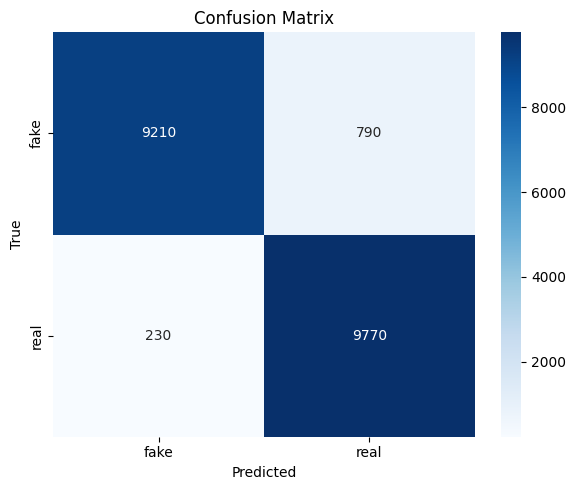

In [7]:

conf_mat = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
